In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

In [2]:
clinical = pd.read_csv(
    "../data/processed/tcga_brca_clinical_clean.csv"
)

print("Shape:", clinical.shape)
clinical.head()

Shape: (1098, 17)


,case_id,patient_id,sex,race,ethnicity,age_at_diagnosis_days,age_at_diagnosis_years,primary_diagnosis,stage,pathologic_T,pathologic_N,pathologic_M,vital_status,days_to_death,latest_follow_up_days,overall_survival_days,overall_survival_event
0,001cef41-ff86-4d3f-a140-a647ac4b10a1,TCGA-E2-A1IU,female,white,not hispanic or latino,22279.0,60.996578,"Infiltrating duct carcinoma, NOS",Stage IA,T1c,N0 (mol+),M0,Alive,NaN,337.0,337.0,0.0
1,0045349c-69d9-4306-a403-c9c1fa836644,TCGA-A1-A0SB,female,white,not hispanic or latino,25833.0,70.726899,Adenoid cystic carcinoma,Stage I,T1c,N0,M0,Alive,NaN,259.0,259.0,0.0
2,00807dae-9f4a-4fd1-aac2-82eb11bf2afb,TCGA-A2-A04W,female,white,not hispanic or latino,18345.0,50.225873,Apocrine adenocarcinoma,Stage IIB,T2,N1mi,M0,Alive,NaN,3102.0,3102.0,0.0
3,00a2d166-78c9-4687-a195-3d6315c27574,TCGA-AN-A0AM,female,white,not hispanic or latino,20713.0,56.709103,"Infiltrating duct carcinoma, NOS",Stage IIA,T2,N0,M0,Alive,NaN,5.0,5.0,0.0
4,00b11ca8-8540-4a3d-b602-ec754b00230b,TCGA-LL-A440,female,white,not hispanic or latino,22497.0,61.593429,"Lobular carcinoma, NOS",Stage IA,T1c,N0 (i-),MX,Alive,NaN,759.0,759.0,0.0


In [3]:
survival_df = clinical[
    clinical["overall_survival_days"].notna()
    & clinical["overall_survival_event"].notna()
].copy()

print("Patients usable for survival analysis:", len(survival_df))

Patients usable for survival analysis: 1094


In [4]:
survival_df["overall_survival_event"].value_counts()

overall_survival_event
0.0    943
1.0    151
Name: count, dtype: int64

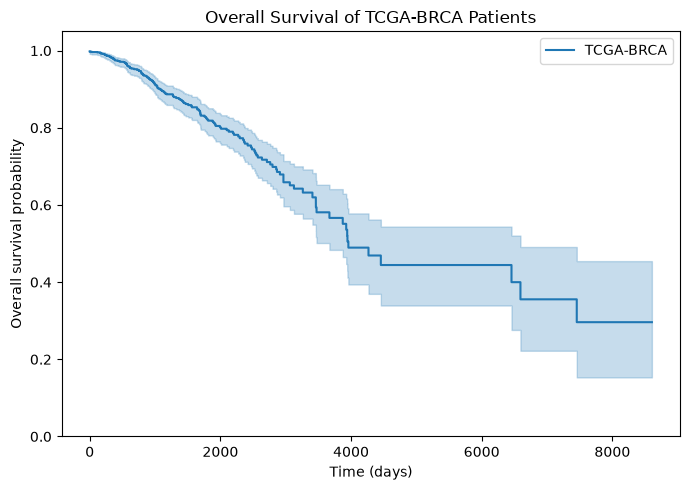

In [5]:
kmf = KaplanMeierFitter()

kmf.fit(
    durations=survival_df["overall_survival_days"],
    event_observed=survival_df["overall_survival_event"],
    label="TCGA-BRCA"
)

plt.figure(figsize=(7, 5))

kmf.plot_survival_function()

plt.xlabel("Time (days)")
plt.ylabel("Overall survival probability")
plt.title("Overall Survival of TCGA-BRCA Patients")

plt.ylim(0, 1.05)
plt.tight_layout()

plt.show()

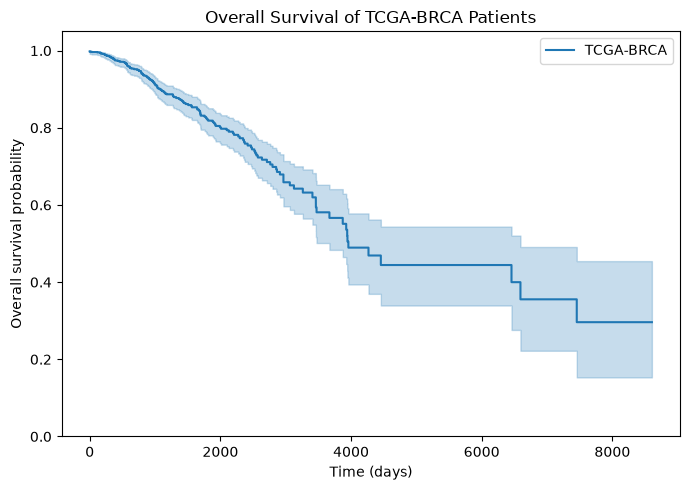

In [6]:
figures_dir = Path("../figures")
figures_dir.mkdir(exist_ok=True)

kmf = KaplanMeierFitter()

kmf.fit(
    durations=survival_df["overall_survival_days"],
    event_observed=survival_df["overall_survival_event"],
    label="TCGA-BRCA"
)

plt.figure(figsize=(7, 5))

kmf.plot_survival_function()

plt.xlabel("Time (days)")
plt.ylabel("Overall survival probability")
plt.title("Overall Survival of TCGA-BRCA Patients")

plt.ylim(0, 1.05)
plt.tight_layout()

plt.savefig(
    figures_dir / "overall_survival_km.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
print("Number of patients:", len(survival_df))

print(
    "Number of deaths:",
    int(survival_df["overall_survival_event"].sum())
)

print(
    "Median survival time:",
    kmf.median_survival_time_
)

Number of patients: 1094
Number of deaths: 151
Median survival time: 3959.0


In [9]:
def simplify_stage(stage):
    if pd.isna(stage):
        return pd.NA

    stage = str(stage).strip()

    if stage in ["Stage I", "Stage IA", "Stage IB"]:
        return "Stage I"

    elif stage in ["Stage II", "Stage IIA", "Stage IIB"]:
        return "Stage II"

    elif stage in ["Stage III", "Stage IIIA", "Stage IIIB", "Stage IIIC"]:
        return "Stage III"

    elif stage == "Stage IV":
        return "Stage IV"

    else:
        return pd.NA


clinical["stage_group"] = clinical["stage"].apply(simplify_stage)

In [10]:
stage_survival = clinical[
    clinical["overall_survival_days"].notna()
    & clinical["overall_survival_event"].notna()
    & clinical["stage_group"].notna()
].copy()

print(
    "Patients in stage survival analysis:",
    len(stage_survival)
)

stage_survival["stage_group"].value_counts()

Patients in stage survival analysis: 1070


stage_group
Stage II     620
Stage III    248
Stage I      182
Stage IV      20
Name: count, dtype: int64

In [11]:
stage_event_summary = (
    stage_survival
    .groupby("stage_group")
    .agg(
        patients=("patient_id", "count"),
        deaths=("overall_survival_event", "sum")
    )
    .reindex(["Stage I", "Stage II", "Stage III", "Stage IV"])
)

stage_event_summary

,patients,deaths
stage_group,,
Stage I,182,16.0
Stage II,620,65.0
Stage III,248,44.0
Stage IV,20,15.0


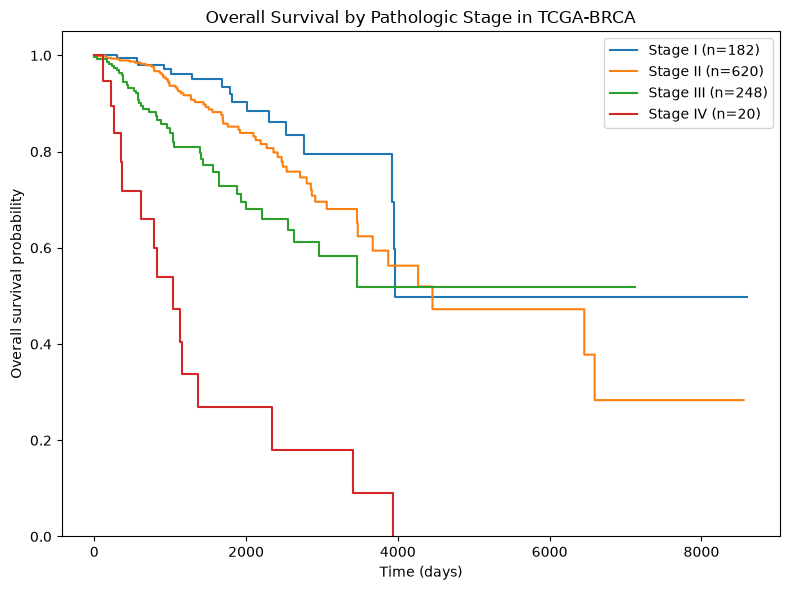

In [12]:
stage_order = ["Stage I", "Stage II", "Stage III", "Stage IV"]

plt.figure(figsize=(8, 6))

for stage in stage_order:
    subset = stage_survival[
        stage_survival["stage_group"] == stage
    ]

    kmf_stage = KaplanMeierFitter()

    kmf_stage.fit(
        durations=subset["overall_survival_days"],
        event_observed=subset["overall_survival_event"],
        label=f"{stage} (n={len(subset)})"
    )

    kmf_stage.plot_survival_function(ci_show=False)

plt.xlabel("Time (days)")
plt.ylabel("Overall survival probability")
plt.title("Overall Survival by Pathologic Stage in TCGA-BRCA")

plt.ylim(0, 1.05)
plt.tight_layout()

plt.show()

In [13]:
logrank_result = multivariate_logrank_test(
    event_durations=stage_survival["overall_survival_days"],
    groups=stage_survival["stage_group"],
    event_observed=stage_survival["overall_survival_event"]
)

logrank_result.print_summary()

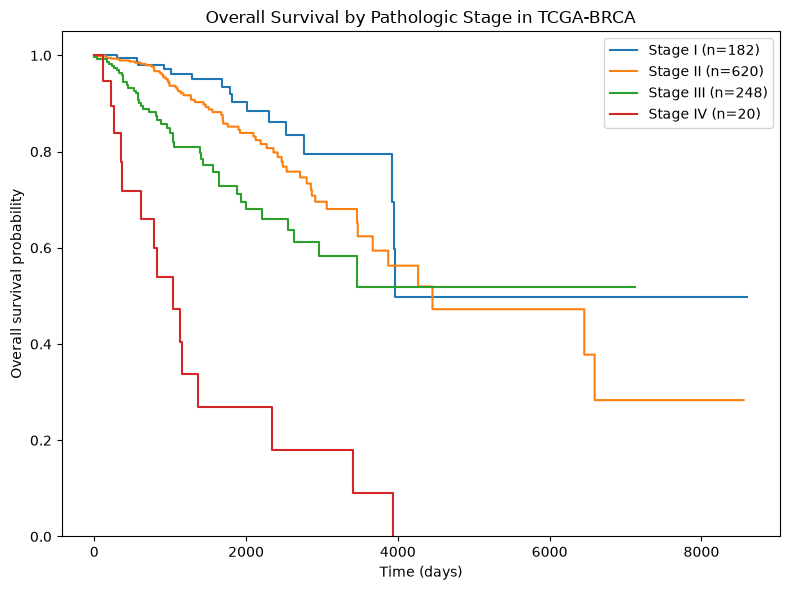

In [14]:
stage_order = ["Stage I", "Stage II", "Stage III", "Stage IV"]

plt.figure(figsize=(8, 6))

for stage in stage_order:
    subset = stage_survival[
        stage_survival["stage_group"] == stage
    ]

    kmf_stage = KaplanMeierFitter()

    kmf_stage.fit(
        durations=subset["overall_survival_days"],
        event_observed=subset["overall_survival_event"],
        label=f"{stage} (n={len(subset)})"
    )

    kmf_stage.plot_survival_function(ci_show=False)

plt.xlabel("Time (days)")
plt.ylabel("Overall survival probability")
plt.title("Overall Survival by Pathologic Stage in TCGA-BRCA")

plt.ylim(0, 1.05)
plt.tight_layout()

plt.savefig(
    "../figures/overall_survival_by_stage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
from lifelines.statistics import pairwise_logrank_test

pairwise_results = pairwise_logrank_test(
    stage_survival["overall_survival_days"],
    stage_survival["stage_group"],
    stage_survival["overall_survival_event"]
)

pairwise_results.summary

test_statistic             p   -log2(p)
Stage I   Stage II         2.669078  1.023153e-01   3.288907
          Stage III       13.778663  2.056587e-04  12.247460
          Stage IV        77.736529  1.177436e-18  59.559057
Stage II  Stage III       11.637537  6.463414e-04  10.595416
          Stage IV        74.944580  4.841144e-18  57.519358
Stage III Stage IV        27.123813  1.908327e-07  22.321188

In [16]:
pairwise_summary = pairwise_results.summary.copy()

n_comparisons = len(pairwise_summary)

pairwise_summary["p_bonferroni"] = (
    pairwise_summary["p"] * n_comparisons
).clip(upper=1)

pairwise_summary["significant_bonferroni"] = (
    pairwise_summary["p_bonferroni"] < 0.05
)

pairwise_summary

test_statistic             p   -log2(p)  p_bonferroni  \
Stage I   Stage II         2.669078  1.023153e-01   3.288907  6.138916e-01   
          Stage III       13.778663  2.056587e-04  12.247460  1.233952e-03   
          Stage IV        77.736529  1.177436e-18  59.559057  7.064614e-18   
Stage II  Stage III       11.637537  6.463414e-04  10.595416  3.878049e-03   
          Stage IV        74.944580  4.841144e-18  57.519358  2.904687e-17   
Stage III Stage IV        27.123813  1.908327e-07  22.321188  1.144996e-06   

                     significant_bonferroni  
Stage I   Stage II                    False  
          Stage III                    True  
          Stage IV                     True  
Stage II  Stage III                    True  
          Stage IV                     True  
Stage III Stage IV                     True

In [17]:
pairwise_summary.to_csv(
    "../results/stage_pairwise_logrank_results.csv"
)

print("Pairwise log-rank results saved.")

Pairwise log-rank results saved.


In [18]:
global_logrank_summary = pd.DataFrame({
    "test": ["Multivariate log-rank test"],
    "test_statistic": [logrank_result.test_statistic],
    "degrees_of_freedom": [3],
    "p_value": [logrank_result.p_value]
})

global_logrank_summary.to_csv(
    "../results/stage_global_logrank_result.csv",
    index=False
)

global_logrank_summary

,test,test_statistic,degrees_of_freedom,p_value
0,Multivariate log-rank test,90.902633,3,1.401759e-19


In [19]:
pairwise_summary.to_csv(
    "../results/stage_pairwise_logrank_results.csv"
)

print("Pairwise log-rank results saved successfully.")

Pairwise log-rank results saved successfully.


In [20]:
print("=== FINAL SURVIVAL ANALYSIS QC ===")

print("Total clinical patients:", len(clinical))
print("Patients usable for overall survival:", len(survival_df))
print("Deaths in overall survival analysis:",
      int(survival_df["overall_survival_event"].sum()))

print("Patients usable for stage survival:", len(stage_survival))

print("\nStage distribution:")
print(stage_survival["stage_group"].value_counts())

print("\nGlobal log-rank:")
print("Chi-square:", round(logrank_result.test_statistic, 2))
print("p-value:", logrank_result.p_value)

print("\nPairwise comparisons after Bonferroni correction:")
print(
    pairwise_summary[
        ["p_bonferroni", "significant_bonferroni"]
    ]
)

=== FINAL SURVIVAL ANALYSIS QC ===
Total clinical patients: 1098
Patients usable for overall survival: 1094
Deaths in overall survival analysis: 151
Patients usable for stage survival: 1070

Stage distribution:
stage_group
Stage II     620
Stage III    248
Stage I      182
Stage IV      20
Name: count, dtype: int64

Global log-rank:
Chi-square: 90.9
p-value: 1.4017591801167432e-19

Pairwise comparisons after Bonferroni correction:
                     p_bonferroni  significant_bonferroni
Stage I   Stage II   6.138916e-01                   False
          Stage III  1.233952e-03                    True
          Stage IV   7.064614e-18                    True
Stage II  Stage III  3.878049e-03                    True
          Stage IV   2.904687e-17                    True
Stage III Stage IV   1.144996e-06                    True
